# Tutorial: MOSTA Brain Cell Composition Review

Audience:
- Researchers reviewing MOSTA focus-anchor interpolation results and classifier-derived cell compositions.

Prerequisites:
- The downstream run directory `results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025` exists.
- `anndata`, `pandas`, `numpy`, and `matplotlib` are available in the notebook kernel.

Learning goals:
- Load all saved gene-space `h5ad` files across observed and interpolated time points.
- Summarize cell-type counts and proportions from classifier-derived `Annotation` labels.
- Draw a clean stacked barplot for temporal cell composition in a Nature-style presentation.


## Outline

1. Locate the MOSTA run outputs and load metadata.
2. Aggregate cell counts and proportions across all time points.
3. Plot a publication-style stacked barplot with controllable category collapsing.
4. Rebuild latent slices and visualize Brain growth-rate maps across time.


In [1]:
from __future__ import annotations

from pathlib import Path
import os
import json
import re
import sys

os.environ.setdefault("MPLCONFIGDIR", os.path.join("/tmp", "mosta_mplconfig"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join("/tmp", "mosta_xdg_cache"))

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 160
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.linewidth"] = 0.8
plt.rcParams["xtick.major.width"] = 0.8
plt.rcParams["ytick.major.width"] = 0.8
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "results").exists():
            return candidate
    hint = Path("/Users/zhenyizhang/Desktop/CytoBridge-ST-1104")
    if hint.exists():
        return hint
    raise FileNotFoundError("Could not locate the CytoBridge-ST-1104 repo root.")

REPO = find_repo_root(Path.cwd())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
RESULT_DIR = REPO / "results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025"
MANIFEST = RESULT_DIR / "analysis_manifest.json"
LABEL_TO_COLOR_PATH = REPO / "results/mosta_interp_0_3_0208_n_pc_12/label_to_color.json"

manifest = json.loads(MANIFEST.read_text())
GENE_H5AD_DIR = Path(manifest["gene_h5ad_dir"])
FIG_DIR = Path(manifest["figures_dir"])
TABLE_DIR = Path(manifest["tables_dir"])
SVG_EXPORT_DIR = FIG_DIR / "review_svg"
SVG_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
label_to_color = json.loads(LABEL_TO_COLOR_PATH.read_text()) if LABEL_TO_COLOR_PATH.exists() else {}

time_pattern = re.compile(r"adata_t(?P<token>.+?)_with_genes\.h5ad$")

def token_to_time(path: Path) -> float:
    match = time_pattern.search(path.name)
    if not match:
        raise ValueError(f"Could not parse time token from {path.name}")
    return float(match.group("token").replace("p", ".").replace("n", "-"))

h5ad_paths = sorted(GENE_H5AD_DIR.glob("adata_t*_with_genes.h5ad"), key=token_to_time)
print("RESULT_DIR:", RESULT_DIR)
print("GENE_H5AD_DIR:", GENE_H5AD_DIR)
print("classifier_acc:", manifest.get("classifier_acc"))
print("SVG_EXPORT_DIR:", SVG_EXPORT_DIR)
print("n_timepoints:", len(h5ad_paths))
print("times:", [token_to_time(p) for p in h5ad_paths])


RESULT_DIR: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025
GENE_H5AD_DIR: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/gene_h5ad
classifier_acc: 0.8715014088675954
SVG_EXPORT_DIR: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/review_svg
n_timepoints: 13
times: [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]


## Step 1 - Load classifier-derived cell labels across all time points

Each saved `h5ad` contains an `Annotation` column in `obs`. For interpolated time points, these labels come from the trained classifier used in the upstream MOSTA run. The next cell aggregates counts and proportions across all observed and interpolated time points.


In [2]:
records = []
for path in h5ad_paths:
    adata = ad.read_h5ad(path)
    if "Annotation" not in adata.obs.columns:
        raise KeyError(f"Annotation column missing in {path}")
    time_value = token_to_time(path)
    counts = adata.obs["Annotation"].astype(str).value_counts().sort_index()
    total = int(counts.sum())
    for cell_type, n_cells in counts.items():
        records.append(
            {
                "time": float(time_value),
                "cell_type": str(cell_type),
                "n_cells": int(n_cells),
                "total_cells": total,
                "fraction": float(n_cells / total),
            }
        )

comp_df = pd.DataFrame(records).sort_values(["time", "cell_type"], kind="stable").reset_index(drop=True)
count_table = comp_df.pivot(index="time", columns="cell_type", values="n_cells").fillna(0).astype(int)
fraction_table = comp_df.pivot(index="time", columns="cell_type", values="fraction").fillna(0.0)
summary_df = pd.DataFrame(
    {
        "time": count_table.index.to_numpy(dtype=float),
        "n_cells": count_table.sum(axis=1).to_numpy(dtype=int),
        "n_cell_types": (count_table > 0).sum(axis=1).to_numpy(dtype=int),
    }
)

display(summary_df)
display(comp_df.head())


,time,n_cells,n_cell_types
0,0.00,20234,22
1,0.25,22425,22
2,0.50,24958,25
3,0.75,27433,23
4,1.00,29916,24
5,1.25,32392,23
6,1.50,34793,23
7,1.75,37103,24
8,2.00,39089,26
9,2.25,40713,27


,time,cell_type,n_cells,total_cells,fraction
0,0.0,Blood vessel,649,20234,0.032075
1,0.0,Brain,4783,20234,0.236384
2,0.0,Cartilage primordium,1464,20234,0.072353
3,0.0,Cavity,2473,20234,0.122220
4,0.0,Choroid plexus,93,20234,0.004596


## Step 2 - Plot a Nature-style stacked barplot

The default view keeps the most abundant cell types and merges the long tail into `Other`, which is usually more readable for a figure panel. Set `TOP_N_CELL_TYPES = None` if you want to keep all categories separate.


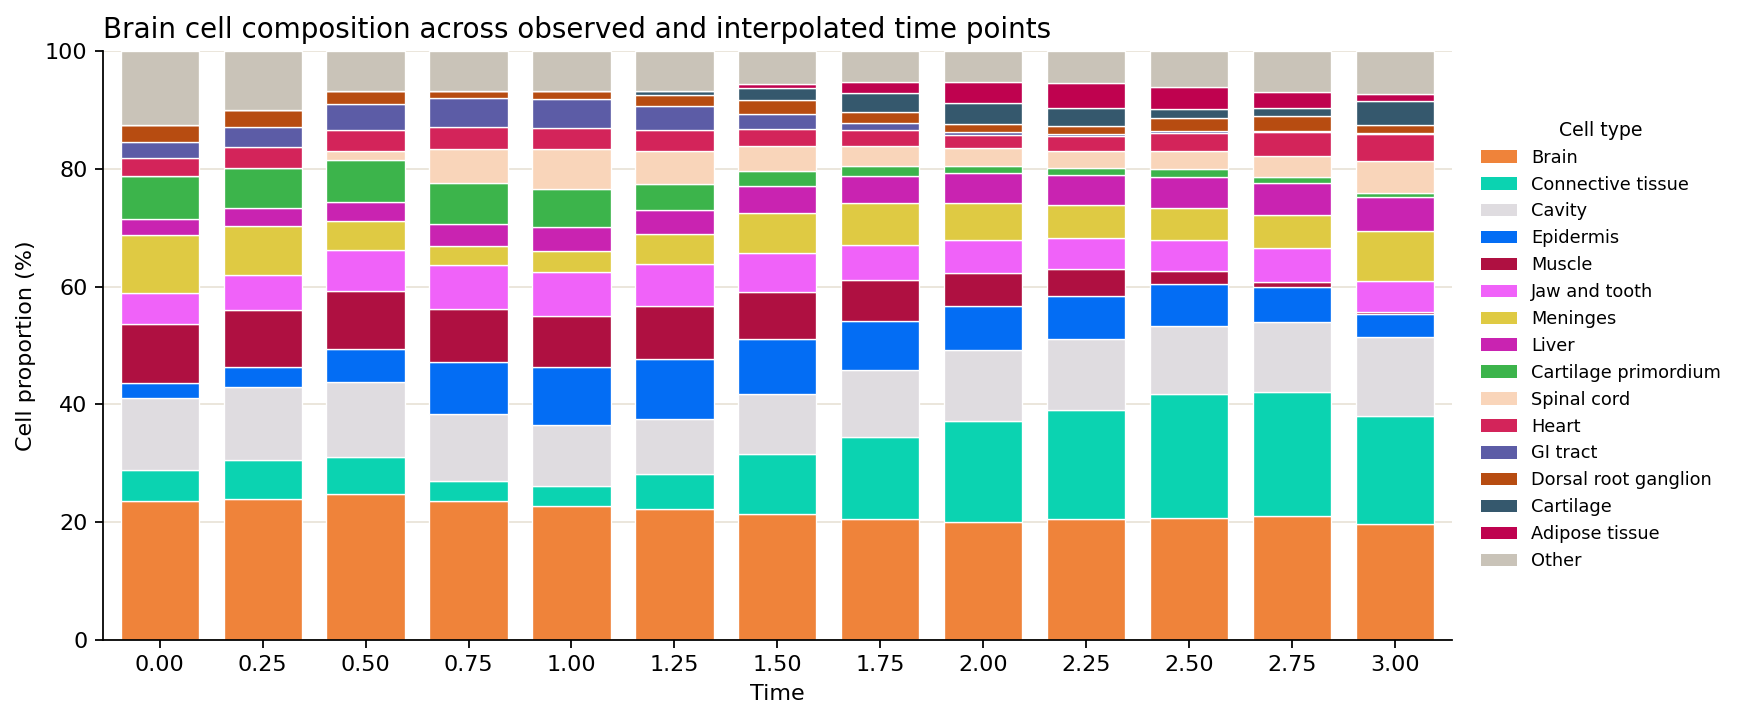

saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/review_svg/brain_cell_composition_stacked_bar.svg


cell_type,Brain,Connective tissue,Cavity,Epidermis,Muscle,Jaw and tooth,Meninges,Liver,Cartilage primordium,Spinal cord,Heart,GI tract,Dorsal root ganglion,Cartilage,Adipose tissue,Other
time,,,,,,,,,,,,,,,,
0.00,23.64,5.22,12.22,2.47,10.12,5.28,9.82,2.79,7.24,0.00,3.07,2.79,2.88,0.00,0.00,12.45
0.25,23.98,6.56,12.48,3.32,9.66,5.96,8.29,3.04,6.89,0.00,3.48,3.41,2.92,0.00,0.00,10.01
0.50,24.70,6.30,12.79,5.70,9.75,6.97,4.96,3.25,7.13,1.51,3.51,4.54,2.07,0.00,0.00,6.83
0.75,23.49,3.38,11.42,8.93,9.01,7.39,3.28,3.72,7.07,5.69,3.80,4.89,1.20,0.00,0.00,6.72
1.00,22.68,3.43,10.36,9.84,8.74,7.48,3.46,4.10,6.53,6.72,3.67,4.95,1.29,0.05,0.01,6.69
1.25,22.15,6.06,9.34,10.11,8.99,7.21,5.04,4.17,4.45,5.50,3.57,4.06,1.90,0.70,0.03,6.71
1.50,21.34,10.21,10.22,9.33,7.95,6.69,6.82,4.49,2.62,4.19,2.85,2.62,2.39,1.96,0.73,5.57
1.75,20.46,14.06,11.34,8.34,6.95,6.00,6.99,4.74,1.59,3.51,2.64,1.25,1.76,3.22,1.86,5.29
2.00,20.07,17.17,11.98,7.48,5.67,5.57,6.29,5.02,1.21,3.07,2.27,0.57,1.23,3.67,3.59,5.15


In [3]:
TOP_N_CELL_TYPES =15
SAVE_FIGURE = True
OUT_PATH = SVG_EXPORT_DIR / "brain_cell_composition_stacked_bar.svg"

global_order = fraction_table.mean(axis=0).sort_values(ascending=False)
if TOP_N_CELL_TYPES is None:
    selected = list(global_order.index)
else:
    selected = list(global_order.head(int(TOP_N_CELL_TYPES)).index)

plot_df = fraction_table.copy()
if len(selected) < plot_df.shape[1]:
    plot_df["Other"] = plot_df.drop(columns=selected).sum(axis=1)
    plot_df = plot_df[selected + ["Other"]]
else:
    plot_df = plot_df[selected]

plot_df = plot_df.sort_index()
plot_df_pct = plot_df * 100.0

colors = []
for cell_type in plot_df_pct.columns:
    if cell_type == "Other":
        colors.append("#c9c3b8")
    else:
        colors.append(label_to_color.get(cell_type, "#808080"))

fig, ax = plt.subplots(figsize=(11.0, 4.6), facecolor="white")
bottom = np.zeros(plot_df_pct.shape[0], dtype=float)
x = np.arange(plot_df_pct.shape[0], dtype=float)

for cell_type, color in zip(plot_df_pct.columns, colors):
    values = plot_df_pct[cell_type].to_numpy(dtype=float)
    ax.bar(
        x,
        values,
        bottom=bottom,
        width=0.76,
        color=color,
        edgecolor="white",
        linewidth=0.6,
        label=cell_type,
    )
    bottom += values

ax.set_xlim(-0.55, len(x) - 0.45)
ax.set_ylim(0, 100)
ax.set_ylabel("Cell proportion (%)")
ax.set_xlabel("Time")
ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in plot_df_pct.index], rotation=0)
ax.set_yticks(np.arange(0, 101, 20))
ax.grid(axis="y", color="#e9e3d8", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_title("Brain cell composition across observed and interpolated time points", loc="left", fontsize=12.5)

legend = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="Cell type",
    ncol=1,
    fontsize=8,
    title_fontsize=8.5,
)
legend_handles = getattr(legend, "legendHandles", None)
if legend_handles is None:
    legend_handles = getattr(legend, "legend_handles", [])
for handle in legend_handles:
    if hasattr(handle, "set_linewidth"):
        handle.set_linewidth(0)

plt.tight_layout()
plt.show()

if SAVE_FIGURE:
    fig.savefig(OUT_PATH, bbox_inches="tight", format="svg")
    print("saved:", OUT_PATH)

display(plot_df_pct.round(2))


## Step 3 - Add an absolute-count companion plot

The stacked barplot emphasizes composition. This companion area plot shows how the absolute number of classifier-assigned cells changes across time, which helps distinguish proportion shifts from overall expansion.


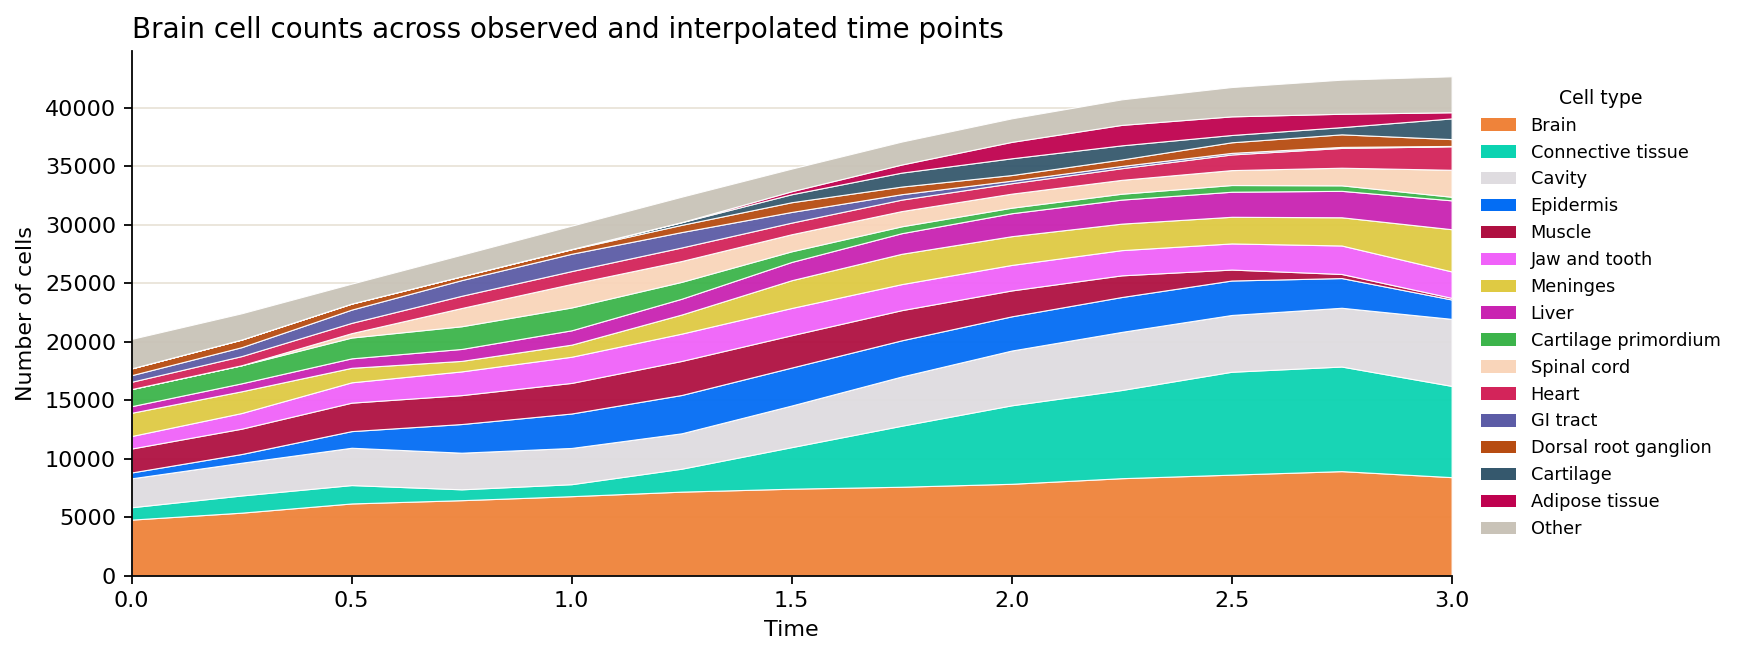

saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/review_svg/brain_cell_composition_area_counts.svg


cell_type,Brain,Connective tissue,Cavity,Epidermis,Muscle,Jaw and tooth,Meninges,Liver,Cartilage primordium,Spinal cord,Heart,GI tract,Dorsal root ganglion,Cartilage,Adipose tissue,Other
time,,,,,,,,,,,,,,,,
0.00,4783,1057,2473,500,2047,1069,1987,565,1464,0,622,564,583,0,0,2520
0.25,5377,1470,2799,745,2167,1337,1859,682,1546,0,780,764,654,0,0,2245
0.50,6164,1572,3191,1422,2433,1739,1239,811,1779,376,877,1134,517,0,0,1704
0.75,6444,928,3132,2450,2472,2028,899,1021,1940,1561,1043,1341,330,0,0,1844
1.00,6786,1026,3098,2945,2615,2238,1034,1226,1953,2011,1099,1480,386,16,3,2000
1.25,7174,1962,3026,3275,2911,2335,1633,1351,1443,1782,1158,1316,617,226,10,2173
1.50,7426,3554,3557,3245,2765,2329,2374,1562,910,1459,993,912,832,683,255,1937
1.75,7593,5215,4209,3093,2580,2225,2593,1760,591,1301,980,464,652,1193,691,1963
2.00,7845,6710,4682,2923,2216,2179,2458,1962,474,1201,888,222,480,1433,1403,2013


In [4]:
SAVE_AREA_FIGURE = True
AREA_OUT_PATH = SVG_EXPORT_DIR / "brain_cell_composition_area_counts.svg"

count_plot_df = count_table.copy()
if len(selected) < count_plot_df.shape[1]:
    count_plot_df["Other"] = count_plot_df.drop(columns=selected).sum(axis=1)
    count_plot_df = count_plot_df[selected + ["Other"]]
else:
    count_plot_df = count_plot_df[selected]

count_plot_df = count_plot_df.sort_index()
area_colors = []
for cell_type in count_plot_df.columns:
    if cell_type == "Other":
        area_colors.append("#c9c3b8")
    else:
        area_colors.append(label_to_color.get(cell_type, "#808080"))

fig, ax = plt.subplots(figsize=(11.0, 4.2), facecolor="white")
x = count_plot_df.index.to_numpy(dtype=float)
y = [count_plot_df[col].to_numpy(dtype=float) for col in count_plot_df.columns]
ax.stackplot(x, y, colors=area_colors, alpha=0.95, linewidth=0.5, edgecolor="white")
ax.set_xlim(x.min(), x.max())
ax.set_xlabel("Time")
ax.set_ylabel("Number of cells")
ax.set_title("Brain cell counts across observed and interpolated time points", loc="left", fontsize=12.5)
ax.grid(axis="y", color="#e9e3d8", linewidth=0.8)
ax.set_axisbelow(True)

handles = [mpl.patches.Patch(facecolor=color, edgecolor="none", label=cell_type) for cell_type, color in zip(count_plot_df.columns, area_colors)]
legend = ax.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    title="Cell type",
    ncol=1,
    fontsize=8,
    title_fontsize=8.5,
)

plt.tight_layout()
plt.show()

if SAVE_AREA_FIGURE:
    fig.savefig(AREA_OUT_PATH, bbox_inches="tight", format="svg")
    print("saved:", AREA_OUT_PATH)

display(count_plot_df)


## Step 4 - Visualize Brain growth-rate maps across time

Growth is defined in the latent model, not in the reconstructed gene matrix. Because the saved `gene_h5ad` files were written in `minimal` mode, this cell rebuilds the latent slices from the original run, reuses the cached classifier to recover cell labels, and then evaluates `g_net(t, x)` only on cells labeled `Brain`.


[simulate_sde_points_split] start | n_init=5000, ts_points=13, dt=0.05, sigma=0.03, growth_alpha=1.0, t_range=(0.0,3.0), est_steps=60
[simulate_sde_points_split] done | timepoints=13, shape0=(5121, 52)


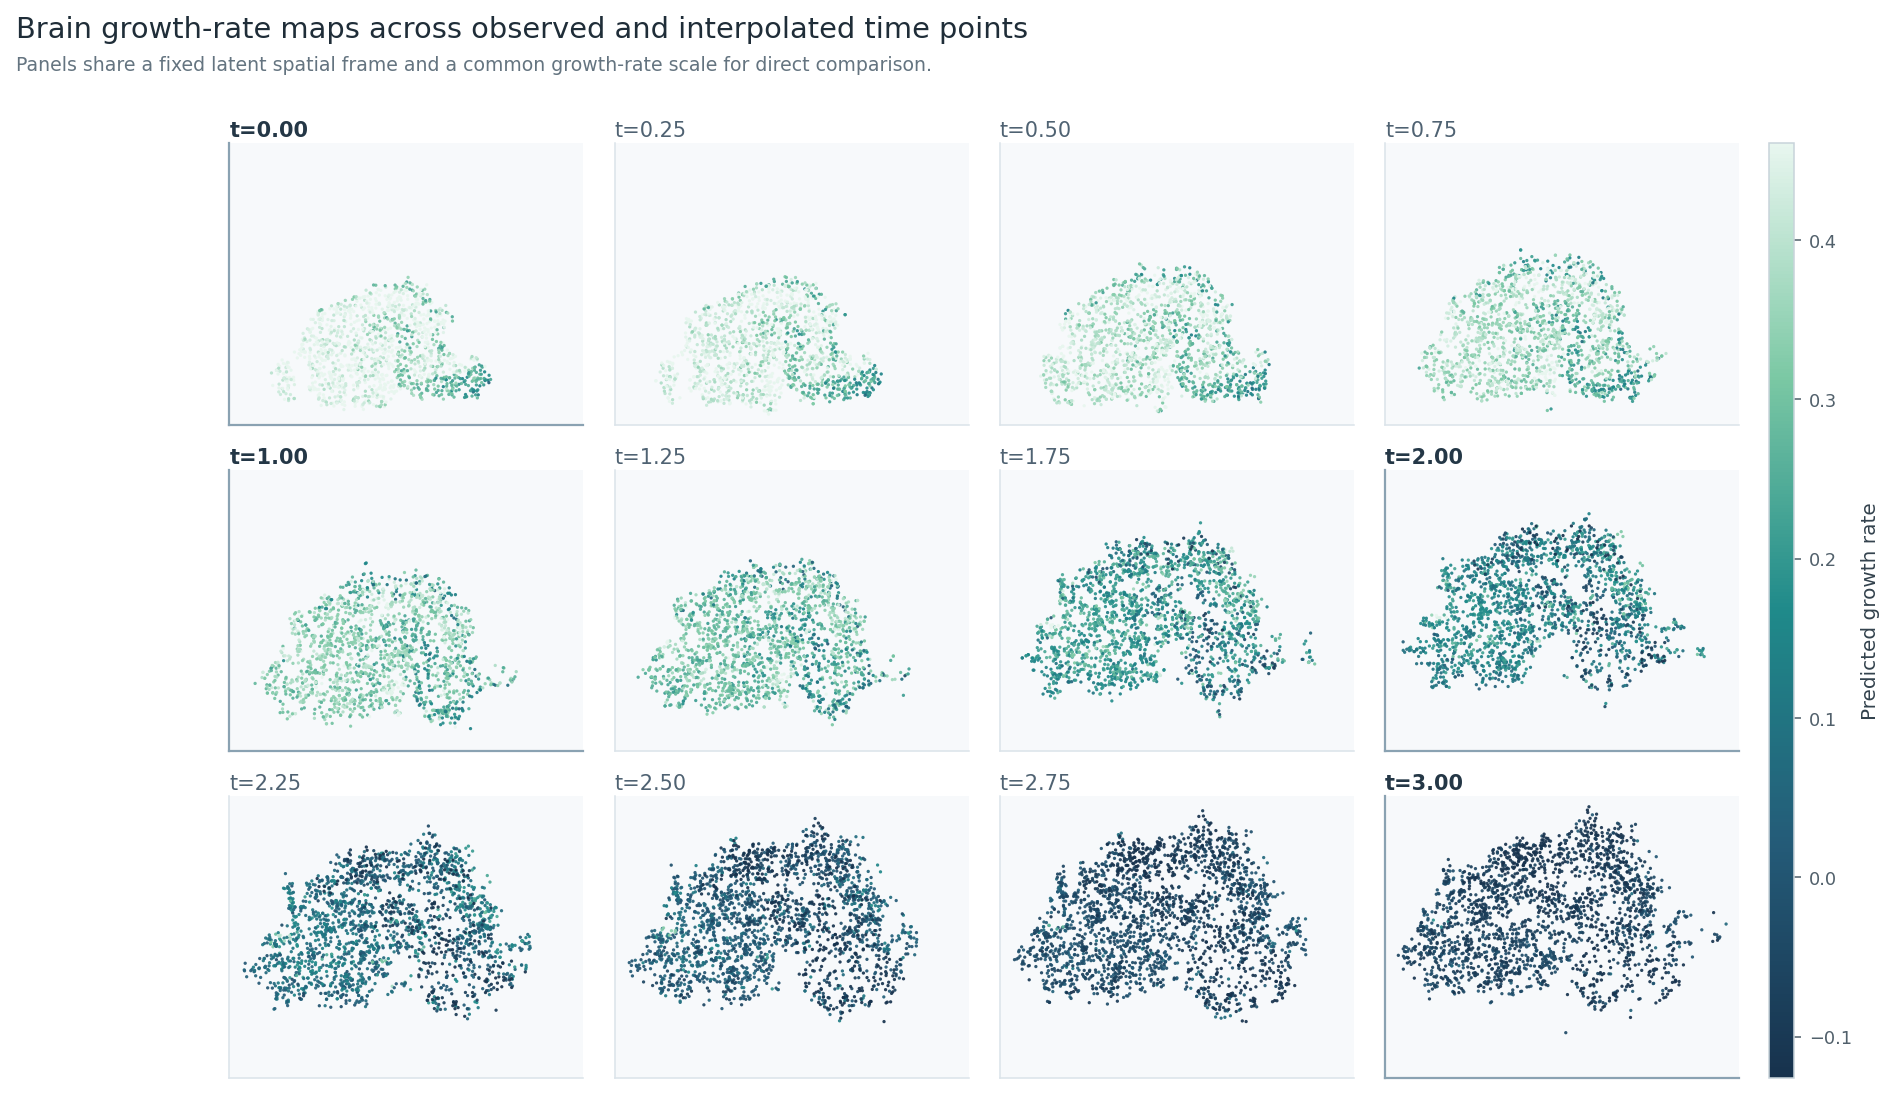

saved: /Users/zhenyizhang/Desktop/CytoBridge-ST-1104/results/mosta_interp_0_3_0208_n_pc_12/gene_pathway_brain_dense025/figures/review_svg/brain_growth_spatiotemporal_map.svg


,count,mean,median,min,max
time,,,,,
0.00,1263,0.4186,0.4309,0.0373,0.7731
0.25,1393,0.3939,0.4089,0.0556,0.7123
0.50,1609,0.3690,0.3827,0.0220,0.6581
0.75,1715,0.3435,0.3564,0.0403,0.6268
1.00,1776,0.3196,0.3283,0.0112,0.6129
1.25,1889,0.2865,0.2925,-0.0395,0.6067
1.50,2024,0.2436,0.2499,-0.0823,0.5545
1.75,2041,0.1863,0.1934,-0.1394,0.5167
2.00,2077,0.1229,0.1301,-0.1843,0.4706


classifier_acc: 0.8715014088675954
n_samples_used_for_simulation: 5000


: 

In [ ]:
from evaluation.arista_code.arista_helpers import (
    load_config,
    load_models,
    predict_labels_for_trajectories,
    simulate_sde_points_split,
    train_mlp_classifier,
)
import torch

TARGET_CELL_TYPE = "Brain"
N_SAMPLES_CAP = 5000  # set to None to use the full run sample count
SAVE_GROWTH_FIGURE = True
GROWTH_OUT_PATH = SVG_EXPORT_DIR / "brain_growth_spatiotemporal_map.svg"
DROP_GROWTH_TIMEPOINT = 1.50  # set to None to keep all panels
GROWTH_CMAP = mpl.colors.LinearSegmentedColormap.from_list(
    "nature_growth",
    ["#17324d", "#245b78", "#1f8a8a", "#7bc8a4", "#e8f6ef"],
)

RUN_DIR = REPO / "results/mosta_interp_0_3_0208_n_pc_12"
RUN_ARGS = json.loads((RUN_DIR / "run_args.json").read_text())
config_path = REPO / RUN_ARGS.get("config", "config/mosta_config.yaml")
data_csv = REPO / RUN_ARGS["data_csv"]
annotation_key = RUN_ARGS.get("annotation_key", "Annotation")

cfg = load_config(str(config_path))
dim = int(cfg["data"]["dim"])
f_net, score_net, exp_dir, device = load_models(
    cfg,
    exp_name=cfg["exp"]["name"],
    device=None,
    model_tag="model_final",
    score_tag="score_model",
)

df_raw = pd.read_csv(data_csv, low_memory=False)
req_cols = ["samples"] + [f"x{i}" for i in range(1, dim + 1)]
df_raw = df_raw[req_cols + [annotation_key]].copy()
df_raw["samples"] = df_raw["samples"].astype(float)
df_raw[annotation_key] = df_raw[annotation_key].astype(str)
df_raw = df_raw.sort_values("samples").reset_index(drop=True)

classifier_feature_dim = max(1, min(int(RUN_ARGS.get("classifier_n_pcs") or dim), dim))
feature_cols = ["samples"] + [f"x{i}" for i in range(1, classifier_feature_dim + 1)]
classifier_cache_dir = RUN_ARGS.get("classifier_cache_dir")
if not classifier_cache_dir and bool(RUN_ARGS.get("classifier_cache", True)):
    classifier_cache_dir = RUN_DIR / "classifier_cache"
else:
    classifier_cache_dir = Path(classifier_cache_dir) if classifier_cache_dir else None
    if classifier_cache_dir is not None and not classifier_cache_dir.is_absolute():
        classifier_cache_dir = REPO / classifier_cache_dir

clf_model, label_encoder, classifier_acc = train_mlp_classifier(
    df=df_raw,
    feature_cols=feature_cols,
    label_col=annotation_key,
    hidden_size=int(RUN_ARGS.get("classifier_hidden", 128)),
    epochs=int(RUN_ARGS.get("classifier_epochs", 500)),
    cache_dir=str(classifier_cache_dir) if classifier_cache_dir is not None else None,
    cache_tag=RUN_ARGS.get("classifier_cache_tag"),
    df_source_path=str(data_csv),
    reuse_if_possible=bool(RUN_ARGS.get("classifier_cache", True)),
    progress=False,
    device=device,
    best_epoch_metric=str(RUN_ARGS.get("classifier_best_metric", "accuracy")),
    train_on_full_data=bool(RUN_ARGS.get("classifier_train_on_full_data", False)),
)

observed_times = sorted(df_raw["samples"].unique().tolist())
start_index = observed_times.index(float(min(observed_times)))
run_sample_count = int((df_raw["samples"] == float(min(observed_times))).sum())
if RUN_ARGS.get("sde_n_samples") is not None:
    run_sample_count = min(run_sample_count, int(RUN_ARGS["sde_n_samples"]))
n_samples = run_sample_count if N_SAMPLES_CAP is None else min(run_sample_count, int(N_SAMPLES_CAP))

if bool(RUN_ARGS.get("split_sde_piecewise", False)):
    raise NotImplementedError("This notebook growth map currently supports the non-piecewise split-SDE branch used by this run.")

ts_points = [float(t) for t in manifest["time_points"]]
split_dt = float(RUN_ARGS.get("split_sde_dt", 0.05))
split_sigma = float(RUN_ARGS.get("split_sigma", 0.03))
split_growth_alpha = float(RUN_ARGS.get("split_growth_alpha", 1.0))

sde_points = simulate_sde_points_split(
    df=df_raw[req_cols],
    dim=dim,
    f_net=f_net,
    score_net=score_net,
    time_index=start_index,
    n_samples=n_samples,
    ts_points=ts_points,
    dt=split_dt,
    sigma=split_sigma,
    growth_alpha=split_growth_alpha,
    interaction_m=1024,
    device=device,
    verbose=True,
)

predicted_labels_list = predict_labels_for_trajectories(
    sde_points=sde_points,
    ts_points=ts_points,
    model=clf_model,
    label_encoder=label_encoder,
    feature_dim=classifier_feature_dim,
    device=device,
    knn_neighbors=10,
)

growth_records = []
for idx, time_value in enumerate(ts_points):
    x_t = np.asarray(sde_points[idx], dtype=np.float32)
    labels_t = np.asarray(predicted_labels_list[idx]).astype(str)
    brain_mask = labels_t == TARGET_CELL_TYPE
    if not np.any(brain_mask):
        continue
    x_brain = x_t[brain_mask]
    x_tensor = torch.tensor(x_brain, dtype=torch.float32, device=device)
    t_tensor = torch.full((x_brain.shape[0], 1), float(time_value), dtype=torch.float32, device=device)
    with torch.no_grad():
        g_vals = f_net.g_net(t_tensor, x_tensor).detach().cpu().numpy().reshape(-1)
    growth_records.append(
        pd.DataFrame(
            {
                "time": float(time_value),
                "x": x_brain[:, 0],
                "y": x_brain[:, 1],
                "growth": g_vals,
            }
        )
    )

brain_growth_df = pd.concat(growth_records, ignore_index=True)
if DROP_GROWTH_TIMEPOINT is None:
    plot_ts_points = list(ts_points)
else:
    plot_ts_points = [t for t in ts_points if not np.isclose(float(t), float(DROP_GROWTH_TIMEPOINT))]

vmin = float(np.percentile(brain_growth_df["growth"], 5))
vmax = float(np.percentile(brain_growth_df["growth"], 95))
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

x_min, x_max = brain_growth_df["x"].min(), brain_growth_df["x"].max()
y_min, y_max = brain_growth_df["y"].min(), brain_growth_df["y"].max()
x_pad = 0.04 * (x_max - x_min)
y_pad = 0.04 * (y_max - y_min)

n_panels = len(plot_ts_points)
n_rows = 3
n_cols = int(np.ceil(n_panels / n_rows))
fig = plt.figure(figsize=(3.02 * n_cols + 0.55, 2.38 * n_rows + 0.45), facecolor="white")
gs = fig.add_gridspec(
    n_rows,
    n_cols + 1,
    width_ratios=([1.0] * n_cols) + [0.07],
    wspace=0.10,
    hspace=0.16,
)
axes = [fig.add_subplot(gs[r, c]) for r in range(n_rows) for c in range(n_cols)]
cax = fig.add_subplot(gs[:, -1])
observed_set = set(float(t) for t in observed_times)

for ax, time_value in zip(axes, plot_ts_points):
    sub = brain_growth_df.loc[brain_growth_df["time"] == float(time_value)]
    ax.scatter(
        sub["x"],
        sub["y"],
        c=np.clip(sub["growth"], vmin, vmax),
        cmap=GROWTH_CMAP,
        norm=norm,
        s=2.2,
        alpha=0.92,
        linewidths=0,
        rasterized=True,
    )
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_facecolor("#f7f9fb")
    observed = float(time_value) in observed_set
    if observed:
        ax.set_title(f"t={time_value:.2f}", loc="left", fontsize=9.4, color="#243746", fontweight="bold", pad=3)
    else:
        ax.set_title(f"t={time_value:.2f}", loc="left", fontsize=9.4, color="#4f6272", pad=3)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0 if observed else 0.7)
        spine.set_color("#8aa2b2" if observed else "#dbe4ea")

for ax in axes[n_panels:]:
    ax.axis("off")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=GROWTH_CMAP)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Predicted growth rate", fontsize=9, color="#33424d")
cbar.ax.tick_params(labelsize=8, width=0.7, length=3, colors="#51606b")
cbar.outline.set_linewidth(0.7)
cbar.outline.set_edgecolor("#c9d4db")

fig.suptitle(
    f"{TARGET_CELL_TYPE} growth-rate maps across observed and interpolated time points",
    x=0.02,
    y=0.985,
    ha="left",
    fontsize=13,
    color="#1f2d38",
)
fig.text(
    0.02,
    0.952,
    "Panels share a fixed latent spatial frame and a common growth-rate scale for direct comparison.",
    ha="left",
    va="top",
    fontsize=8.5,
    color="#647480",
)
plt.show()

if SAVE_GROWTH_FIGURE:
    fig.savefig(GROWTH_OUT_PATH, bbox_inches="tight", format="svg")
    print("saved:", GROWTH_OUT_PATH)

display(
    brain_growth_df.groupby("time")["growth"].agg(["count", "mean", "median", "min", "max"]).round(4)
)
print("classifier_acc:", classifier_acc)
print("n_samples_used_for_simulation:", n_samples)
